In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [2]:
# Major investment banks - these are our surveillance targets
tickers = {
    'JPM': 'JP Morgan',
    'GS': 'Goldman Sachs',
    'BARC.L': 'Barclays',
    'HSBA.L': 'HSBC',
    'MS': 'Morgan Stanley'
}

# Pull 2 years of daily data
raw_data = yf.download(
    list(tickers.keys()),
    start='2023-01-01',
    end='2025-01-01',
    auto_adjust=True
)

print(f"Data shape: {raw_data.shape}")
print(f"\nColumns available: {raw_data.columns.levels[0].tolist()}")
print(f"\nDate range: {raw_data.index[0].date()} to {raw_data.index[-1].date()}")

[*********************100%***********************]  5 of 5 completed

Data shape: (514, 25)

Columns available: ['Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2023-01-03 to 2024-12-31


In [3]:
# Extract closing prices and volume
close_prices = raw_data['Close']
volume_data = raw_data['Volume']

print("=== Closing Prices (last 5 days) ===")
print(close_prices.tail())

print("\n=== Volume Data (last 5 days) ===")
print(volume_data.tail())

=== Closing Prices (last 5 days) ===
Ticker          BARC.L          GS      HSBA.L         JPM          MS
Date                                                                  
2024-12-24  263.451050  568.144104  771.390625  235.018570  122.921455
2024-12-26         NaN  566.623352         NaN  235.823608  123.859871
2024-12-27  264.800568  561.700317  776.486572  233.912888  122.631248
2024-12-30  264.650604  559.136353  781.083069  232.118561  121.654129
2024-12-31  268.049347  558.229736  784.680176  232.496826  121.625114

=== Volume Data (last 5 days) ===
Ticker          BARC.L         GS      HSBA.L        JPM         MS
Date                                                               
2024-12-24   8298189.0   913400.0   3604795.0  3729100.0  2902800.0
2024-12-26         NaN  1092000.0         NaN  4451800.0  3013500.0
2024-12-27  15970484.0  1486000.0  13069986.0  5730200.0  3088100.0
2024-12-30  14724719.0  1265900.0  11565121.0  5723800.0  2637900.0
2024-12-31   9253099.0 

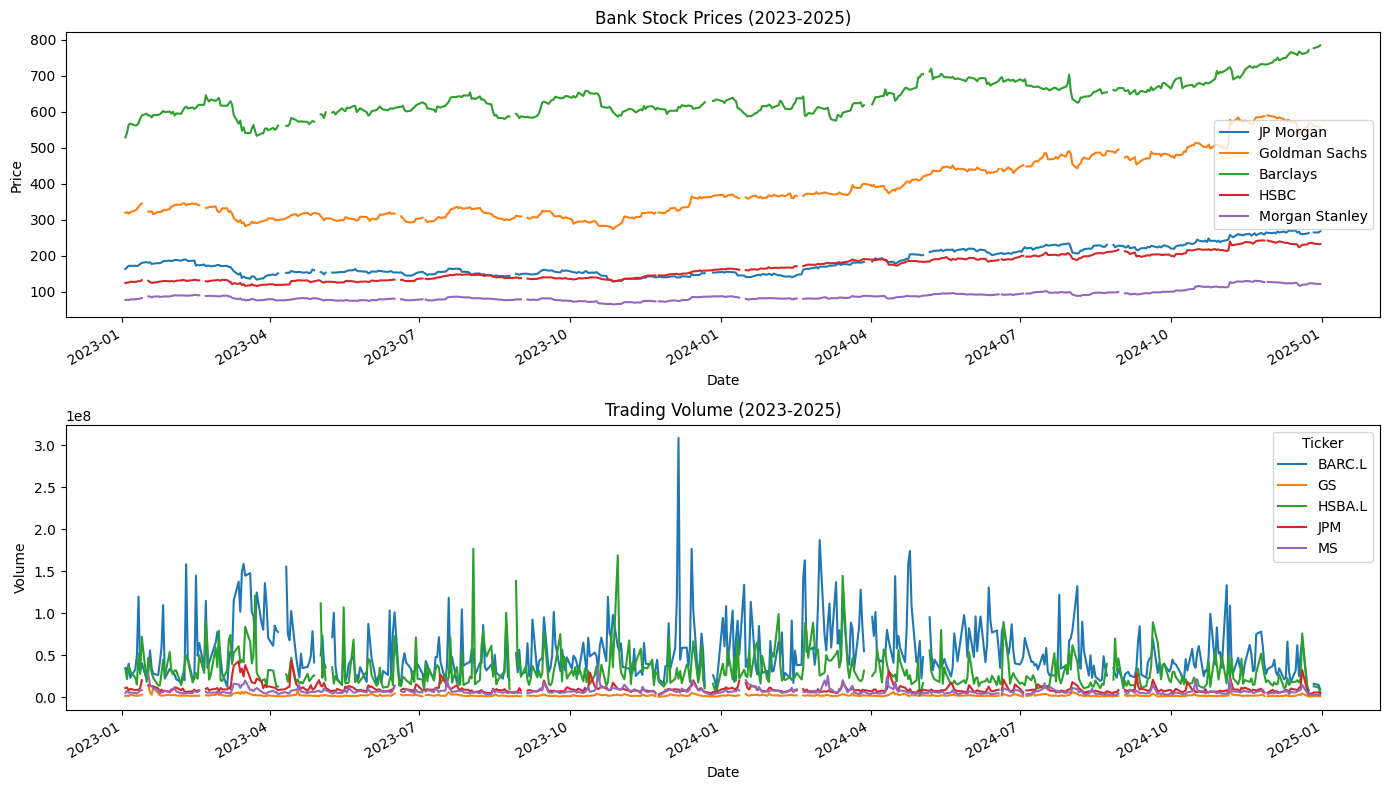

Chart saved to data/ folder ✅


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price chart
close_prices.plot(ax=axes[0], title='Bank Stock Prices (2023-2025)')
axes[0].set_ylabel('Price')
axes[0].legend(tickers.values())

# Volume chart
volume_data.plot(ax=axes[1], title='Trading Volume (2023-2025)')
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.savefig('../data/bank_stocks_overview.png')
plt.show()

print("Chart saved to data/ folder ✅")